# Parameter Sweep: Poisson VAE vs GumbelSoftmaxPoisson VAE

This notebook manages a comprehensive parameter sweep comparing:
- **Poisson VAE** (Thinned Point Process)
- **GumbelSoftmaxPoisson VAE** (Categorical Softmax Approximation)

## Sweep Parameters
| Parameter | Values |
|-----------|--------|
| Distribution | `poisson`, `gumbel` |
| Temperature | 0.01, 0.1, 0.4 |
| Annealing | True, False |
| N_EXP/N_CUTOFF | 16, 64, 256 |
| Seeds | 0, 1, 2 |

**Total Configurations:** 108 (54 per distribution type)

## Step 1: Initialize Job Queue

Run this cell once to create the job queue with all 108 configurations.

In [ ]:
!.venv/bin/python scripts/gpu_sweep_manager.py --init

## Step 2: Start GPU Workers in tmux

Run these commands in a terminal to start 4 GPU workers and a monitoring session:

```bash
# Start a new tmux session
tmux new-session -d -s sweep

# Create 4 GPU worker windows
tmux new-window -t sweep -n gpu0 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 0'
tmux new-window -t sweep -n gpu1 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 1'
tmux new-window -t sweep -n gpu2 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 2'
tmux new-window -t sweep -n gpu3 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 3'

# Create monitoring window
tmux new-window -t sweep -n monitor 'cd /home/michael/code/poisson_notebook && watch -n 10 .venv/bin/python scripts/monitor_sweep.py'

# Attach to the session
tmux attach -t sweep
```

**Or run all at once (copy-paste this block):**

In [ ]:
# Copy this entire block and paste in terminal to start the sweep
tmux_commands = """
tmux new-session -d -s sweep
tmux new-window -t sweep -n gpu0 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 0'
tmux new-window -t sweep -n gpu1 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 1'
tmux new-window -t sweep -n gpu2 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 2'
tmux new-window -t sweep -n gpu3 'cd /home/michael/code/poisson_notebook && .venv/bin/python scripts/gpu_sweep_manager.py --worker --gpu 3'
tmux new-window -t sweep -n monitor 'cd /home/michael/code/poisson_notebook && watch -n 10 .venv/bin/python scripts/monitor_sweep.py'
tmux attach -t sweep
""".strip()

print("Copy and paste the following commands in your terminal:\n")
print(tmux_commands)

## Step 3: Monitor Progress

You can check progress from this notebook while training runs:

In [1]:
import json
from pathlib import Path
from datetime import datetime

def check_sweep_progress():
    """Check current sweep progress."""
    queue_file = Path('./checkpoints/sweep/job_queue.json')
    
    if not queue_file.exists():
        print("No sweep initialized. Run Step 1 first.")
        return
    
    with open(queue_file, 'r') as f:
        data = json.load(f)
    
    jobs = data['jobs']
    
    status_counts = {'pending': 0, 'running': 0, 'completed': 0, 'failed': 0}
    running_jobs = []
    
    for job in jobs:
        if job['status'] == 'pending':
            status_counts['pending'] += 1
        elif job['status'].startswith('running'):
            status_counts['running'] += 1
            running_jobs.append(job)
        elif job['status'] == 'completed':
            status_counts['completed'] += 1
        elif job['status'] == 'failed':
            status_counts['failed'] += 1
    
    total = len(jobs)
    pct = (status_counts['completed'] / total) * 100 if total > 0 else 0
    
    print(f"{'='*60}")
    print(f"  SWEEP PROGRESS - {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*60}")
    print(f"  Completed: {status_counts['completed']:3d}/{total} ({pct:.1f}%)")
    print(f"  Running:   {status_counts['running']:3d}")
    print(f"  Pending:   {status_counts['pending']:3d}")
    print(f"  Failed:    {status_counts['failed']:3d}")
    print()
    
    if running_jobs:
        print("  Currently Running:")
        for job in running_jobs:
            name = f"{job['dist_type']}_temp{job['temp']}_anneal{job['anneal']}_n{job['n_param']}_seed{job['seed']}"
            gpu = job.get('gpu', '?')
            print(f"    GPU {gpu}: {name}")

check_sweep_progress()

  SWEEP PROGRESS - 09:53:03
  Completed: 108/108 (100.0%)
  Running:     0
  Pending:     0
  Failed:      0



---
## Step 4: Analyze Results (After Sweep Completes)

Load all completed experiments and visualize results.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def load_sweep_results():
    """Load all sweep results into a DataFrame."""
    sweep_dir = Path('./checkpoints/sweep')
    results = []
    
    for model_dir in sweep_dir.iterdir():
        if not model_dir.is_dir() or model_dir.name.startswith('.'):
            continue
        
        metrics_file = model_dir / 'metrics.json'
        config_file = model_dir / 'sweep_config.json'
        
        if not metrics_file.exists():
            continue
        
        with open(metrics_file, 'r') as f:
            metrics = json.load(f)
        
        if config_file.exists():
            with open(config_file, 'r') as f:
                config = json.load(f)
        else:
            # Parse config from directory name
            parts = model_dir.name.split('_')
            config = {
                'dist_type': parts[0],
                'temp': float(parts[1].replace('temp', '')),
                'anneal': parts[2].replace('anneal', '') == 'True',
                'n_param': int(parts[3].replace('n', '')),
                'seed': int(parts[4].replace('seed', '')),
            }
        
        results.append({
            **config,
            **metrics,
            'model_dir': str(model_dir),
        })
    
    if not results:
        print("No completed experiments found.")
        return None
    
    df = pd.DataFrame(results)
    print(f"Loaded {len(df)} experiments")
    return df

df = load_sweep_results()
if df is not None:
    display(df.head(10))

Loaded 108 experiments


,dist_type,temp,anneal,n_param,seed,epochs,status,gpu,start_time,config,total_time,n_params,neg_elbo,recon_loss,kl_loss,n_active,lifetime_sparsity,kl_per_dim,model_dir
0,gumbel,0.10,False,2,2,2000,running_gpu1,1,1.767526e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2445.680757,262656,192.422516,166.098434,26.324074,512,0.999162,"[0.046259451657533646, 0.0529220812022686, 0.0...",checkpoints/sweep/gumbel_temp0.1_annealFalse_n...
1,gumbel,0.10,False,4,2,2000,running_gpu2,2,1.767528e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2444.967287,262656,177.266281,143.849640,33.416641,512,0.999846,"[0.06718340516090393, 0.07395902276039124, 0.0...",checkpoints/sweep/gumbel_temp0.1_annealFalse_n...
2,gumbel,0.10,True,2,0,2000,running_gpu0,0,1.767520e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2432.246429,262656,192.967773,166.529968,26.437805,512,0.999137,"[0.04677334055304527, 0.042596060782670975, 0....",checkpoints/sweep/gumbel_temp0.1_annealTrue_n2...
3,gumbel,0.10,True,4,0,2000,running_gpu1,1,1.767521e+09,"{'dist_type': 'gumbel', 'temp': 0.1, 'anneal':...",2481.098038,262656,177.418671,143.977890,33.440784,512,0.999848,"[0.06467925012111664, 0.07016859948635101, 0.0...",checkpoints/sweep/gumbel_temp0.1_annealTrue_n4...
4,gumbel,0.01,True,4,0,2000,running_gpu3,3,1.767511e+09,"{'dist_type': 'gumbel', 'temp': 0.01, 'anneal'...",2478.640823,262656,180.979614,148.330978,32.648640,512,0.417615,"[0.06472042948007584, 0.06654707342386246, 0.0...",checkpoints/sweep/gumbel_temp0.01_annealTrue_n...
5,gumbel,0.40,False,2,0,2000,running_gpu1,1,1.767536e+09,"{'dist_type': 'gumbel', 'temp': 0.4, 'anneal':...",2469.257368,262656,178.510345,152.275314,26.235023,512,1.000000,"[0.04620333015918732, 0.05381670594215393, 0.0...",checkpoints/sweep/gumbel_temp0.4_annealFalse_n...
6,gumbel,0.40,False,2,1,2000,running_gpu0,0,1.767537e+09,"{'dist_type': 'gumbel', 'temp': 0.4, 'anneal':...",2435.677377,262656,177.968292,151.743668,26.224619,512,1.000000,"[0.04782010614871979, 0.05136532336473465, 0.0...",checkpoints/sweep/gumbel_temp0.4_annealFalse_n...
7,gumbel,0.40,False,6,2,2000,running_gpu1,1,1.767541e+09,"{'dist_type': 'gumbel', 'temp': 0.4, 'anneal':...",2482.095616,262656,162.125809,125.592972,36.532837,512,1.000000,"[0.06882093846797943, 0.06927787512540817, 0.0...",checkpoints/sweep/gumbel_temp0.4_annealFalse_n...
8,gumbel,0.40,True,4,2,2000,running_gpu1,1,1.767533e+09,"{'dist_type': 'gumbel', 'temp': 0.4, 'anneal':...",2460.487346,262656,164.689606,131.125885,33.563728,512,1.000000,"[0.06431775540113449, 0.07127141952514648, 0.0...",checkpoints/sweep/gumbel_temp0.4_annealTrue_n4...
9,gumbel,0.01,True,2,2,2000,running_gpu0,0,1.767511e+09,"{'dist_type': 'gumbel', 'temp': 0.01, 'anneal'...",2435.701924,262656,195.549255,170.010864,25.538387,512,0.167715,"[0.0476498045027256, 0.0431828647851944, 0.047...",checkpoints/sweep/gumbel_temp0.01_annealTrue_n...


### Compare Distributions: Neg ELBO vs Parameters

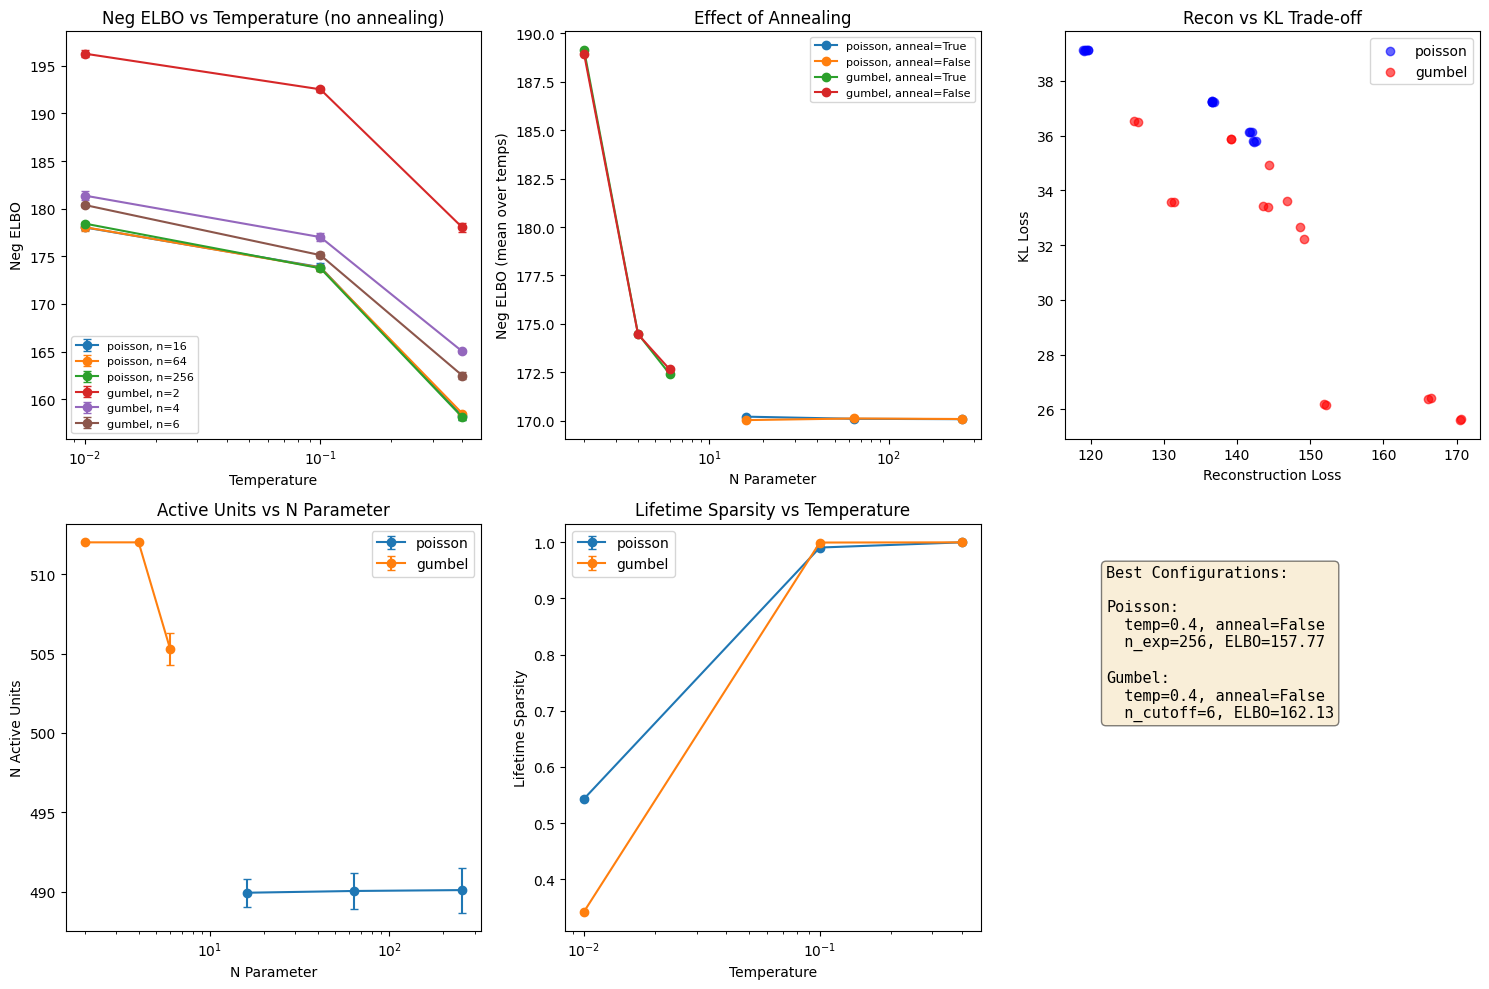

In [3]:
if df is not None and len(df) > 0:
    # Aggregate over seeds
    agg_df = df.groupby(['dist_type', 'temp', 'anneal', 'n_param']).agg({
        'neg_elbo': ['mean', 'std'],
        'recon_loss': ['mean', 'std'],
        'kl_loss': ['mean', 'std'],
        'n_active': ['mean', 'std'],
        'lifetime_sparsity': ['mean', 'std'],
    }).reset_index()
    
    # Flatten column names
    agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot 1: Neg ELBO vs Temperature by Distribution
    ax = axes[0, 0]
    for dist in ['poisson', 'gumbel']:
        subset = agg_df[(agg_df['dist_type'] == dist) & (agg_df['anneal'] == False)]
        for n_param in subset['n_param'].unique():
            data = subset[subset['n_param'] == n_param]
            label = f"{dist}, n={n_param}"
            ax.errorbar(data['temp'], data['neg_elbo_mean'], yerr=data['neg_elbo_std'], 
                       marker='o', label=label, capsize=3)
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Neg ELBO')
    ax.set_title('Neg ELBO vs Temperature (no annealing)')
    ax.legend(fontsize=8)
    ax.set_xscale('log')
    
    # Plot 2: Effect of Annealing
    ax = axes[0, 1]
    for dist in ['poisson', 'gumbel']:
        for anneal in [True, False]:
            subset = agg_df[(agg_df['dist_type'] == dist) & (agg_df['anneal'] == anneal)]
            subset = subset.groupby('n_param').agg({'neg_elbo_mean': 'mean'}).reset_index()
            label = f"{dist}, anneal={anneal}"
            ax.plot(subset['n_param'], subset['neg_elbo_mean'], marker='o', label=label)
    ax.set_xlabel('N Parameter')
    ax.set_ylabel('Neg ELBO (mean over temps)')
    ax.set_title('Effect of Annealing')
    ax.legend(fontsize=8)
    ax.set_xscale('log')
    
    # Plot 3: Reconstruction vs KL Trade-off
    ax = axes[0, 2]
    colors = {'poisson': 'blue', 'gumbel': 'red'}
    for dist in ['poisson', 'gumbel']:
        subset = agg_df[agg_df['dist_type'] == dist]
        ax.scatter(subset['recon_loss_mean'], subset['kl_loss_mean'], 
                  c=colors[dist], alpha=0.6, label=dist)
    ax.set_xlabel('Reconstruction Loss')
    ax.set_ylabel('KL Loss')
    ax.set_title('Recon vs KL Trade-off')
    ax.legend()
    
    # Plot 4: N Active Units
    ax = axes[1, 0]
    for dist in ['poisson', 'gumbel']:
        subset = agg_df[agg_df['dist_type'] == dist]
        subset = subset.groupby('n_param').agg({'n_active_mean': 'mean', 'n_active_std': 'mean'}).reset_index()
        ax.errorbar(subset['n_param'], subset['n_active_mean'], yerr=subset['n_active_std'],
                   marker='o', label=dist, capsize=3)
    ax.set_xlabel('N Parameter')
    ax.set_ylabel('N Active Units')
    ax.set_title('Active Units vs N Parameter')
    ax.legend()
    ax.set_xscale('log')
    
    # Plot 5: Lifetime Sparsity
    ax = axes[1, 1]
    for dist in ['poisson', 'gumbel']:
        subset = agg_df[agg_df['dist_type'] == dist]
        subset = subset.groupby('temp').agg({'lifetime_sparsity_mean': 'mean', 'lifetime_sparsity_std': 'mean'}).reset_index()
        ax.errorbar(subset['temp'], subset['lifetime_sparsity_mean'], yerr=subset['lifetime_sparsity_std'],
                   marker='o', label=dist, capsize=3)
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Lifetime Sparsity')
    ax.set_title('Lifetime Sparsity vs Temperature')
    ax.legend()
    ax.set_xscale('log')
    
    # Plot 6: Best configs table
    ax = axes[1, 2]
    ax.axis('off')
    
    # Find best config for each distribution
    best_poisson = df[df['dist_type'] == 'poisson'].nsmallest(1, 'neg_elbo')
    best_gumbel = df[df['dist_type'] == 'gumbel'].nsmallest(1, 'neg_elbo')
    
    table_text = "Best Configurations:\n\n"
    if len(best_poisson) > 0:
        bp = best_poisson.iloc[0]
        table_text += f"Poisson:\n  temp={bp['temp']}, anneal={bp['anneal']}\n  n_exp={bp['n_param']}, ELBO={bp['neg_elbo']:.2f}\n\n"
    if len(best_gumbel) > 0:
        bg = best_gumbel.iloc[0]
        table_text += f"Gumbel:\n  temp={bg['temp']}, anneal={bg['anneal']}\n  n_cutoff={bg['n_param']}, ELBO={bg['neg_elbo']:.2f}"
    
    ax.text(0.1, 0.9, table_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('./figures/sweep_results.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No results to plot yet.")

### Heatmaps: Temperature × N_param for each Distribution

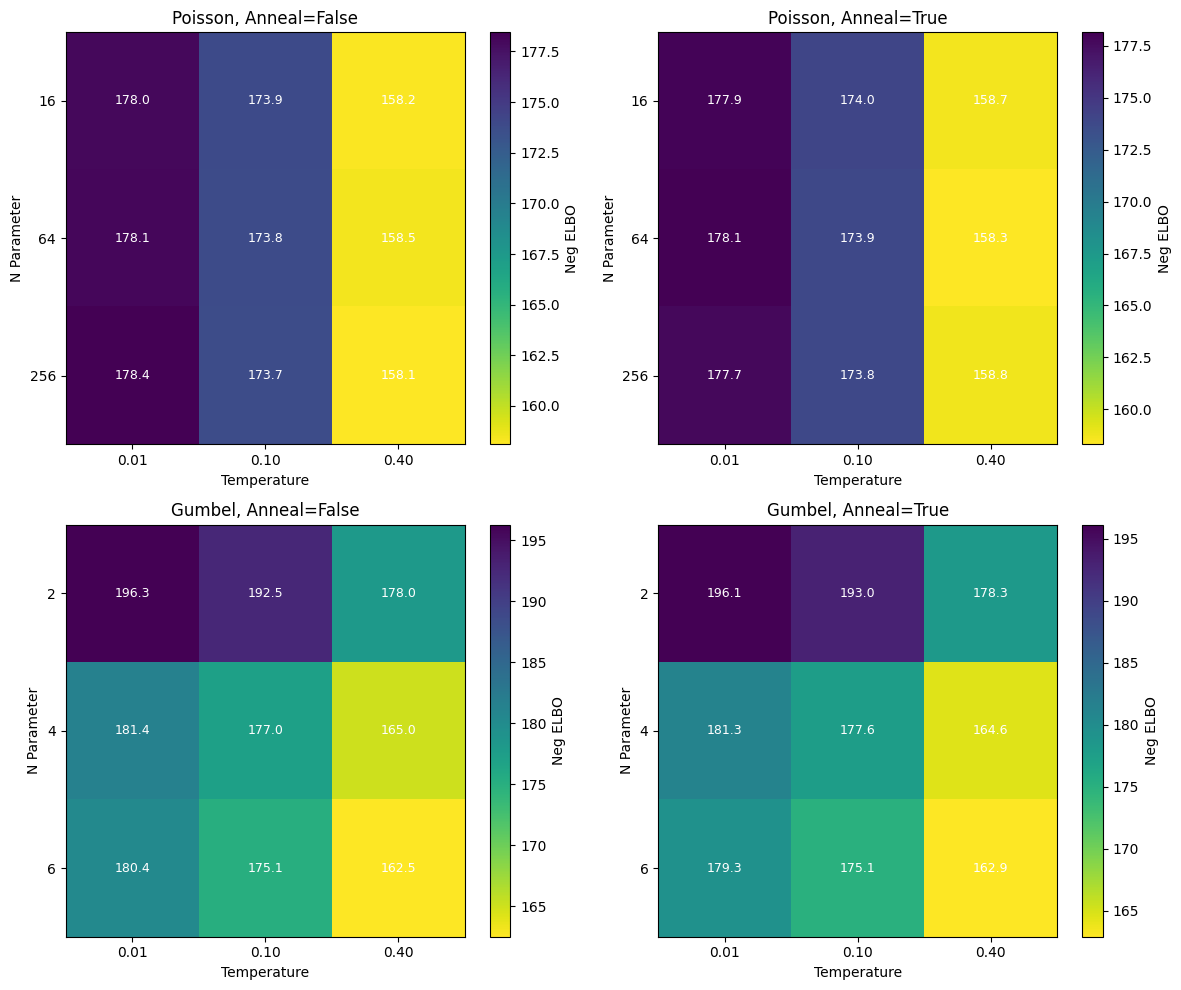

In [4]:
if df is not None and len(df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    temps = sorted(df['temp'].unique())
    n_params = sorted(df['n_param'].unique())
    
    for idx, (dist, anneal) in enumerate([('poisson', False), ('poisson', True), 
                                           ('gumbel', False), ('gumbel', True)]):
        ax = axes[idx // 2, idx % 2]
        
        # Create heatmap data
        subset = df[(df['dist_type'] == dist) & (df['anneal'] == anneal)]
        heatmap_data = subset.pivot_table(values='neg_elbo', index='n_param', 
                                          columns='temp', aggfunc='mean')
        
        if heatmap_data.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{dist.title()}, Anneal={anneal}')
            continue
        
        im = ax.imshow(heatmap_data.values, cmap='viridis_r', aspect='auto')
        
        # Labels
        ax.set_xticks(range(len(heatmap_data.columns)))
        ax.set_xticklabels([f'{t:.2f}' for t in heatmap_data.columns])
        ax.set_yticks(range(len(heatmap_data.index)))
        ax.set_yticklabels(heatmap_data.index)
        
        ax.set_xlabel('Temperature')
        ax.set_ylabel('N Parameter')
        ax.set_title(f'{dist.title()}, Anneal={anneal}')
        
        # Add values
        for i in range(len(heatmap_data.index)):
            for j in range(len(heatmap_data.columns)):
                val = heatmap_data.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.1f}', ha='center', va='center', color='white', fontsize=9)
        
        plt.colorbar(im, ax=ax, label='Neg ELBO')
    
    plt.tight_layout()
    plt.savefig('./figures/sweep_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No results to plot yet.")

### Box Plots: Poisson vs Gumbel by Parameter

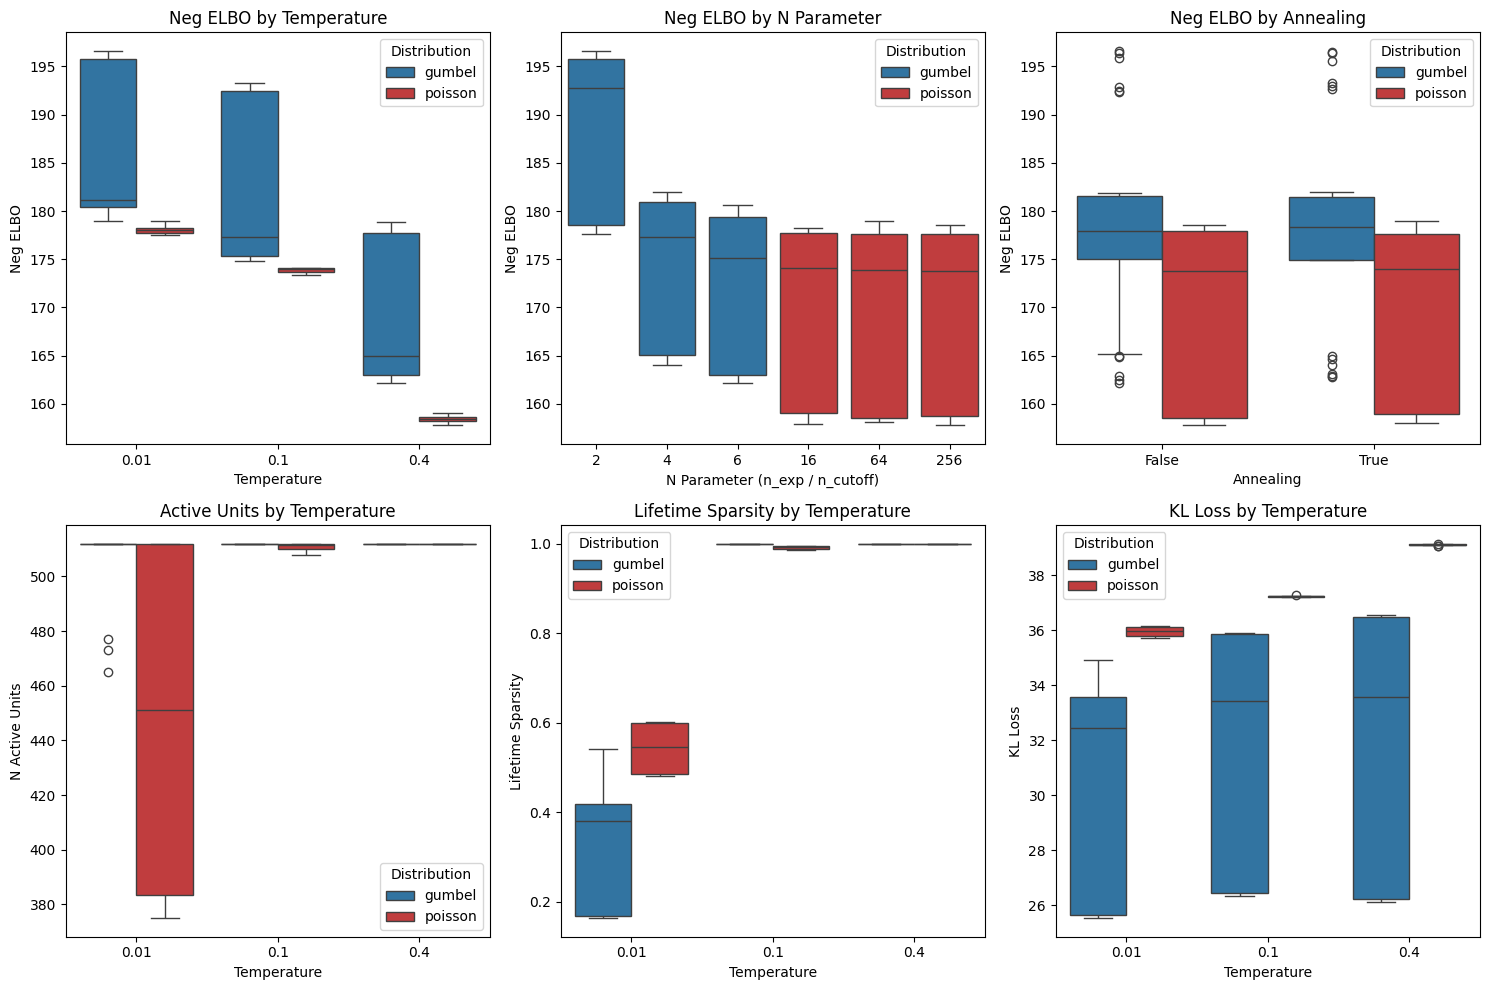

In [10]:
import seaborn as sns

if df is not None and len(df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Box plot by Temperature
    ax = axes[0, 0]
    sns.boxplot(data=df, x='temp', y='neg_elbo', hue='dist_type', ax=ax, palette=['tab:blue', 'tab:red'])
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Neg ELBO')
    ax.set_title('Neg ELBO by Temperature')
    ax.legend(title='Distribution')
    
    # 2. Box plot by N Parameter
    ax = axes[0, 1]
    sns.boxplot(data=df, x='n_param', y='neg_elbo', hue='dist_type', ax=ax, palette=['tab:blue', 'tab:red'])
    ax.set_xlabel('N Parameter (n_exp / n_cutoff)')
    ax.set_ylabel('Neg ELBO')
    ax.set_title('Neg ELBO by N Parameter')
    ax.legend(title='Distribution')
    
    # 3. Box plot by Annealing
    ax = axes[0, 2]
    sns.boxplot(data=df, x='anneal', y='neg_elbo', hue='dist_type', ax=ax, palette=['tab:blue', 'tab:red'])
    ax.set_xlabel('Annealing')
    ax.set_ylabel('Neg ELBO')
    ax.set_title('Neg ELBO by Annealing')
    ax.legend(title='Distribution')
    
    # 4. Box plot of N Active by Temperature
    ax = axes[1, 0]
    sns.boxplot(data=df, x='temp', y='n_active', hue='dist_type', ax=ax, palette=['tab:blue', 'tab:red'])
    ax.set_xlabel('Temperature')
    ax.set_ylabel('N Active Units')
    ax.set_title('Active Units by Temperature')
    ax.legend(title='Distribution')
    
    # 5. Box plot of Lifetime Sparsity by Temperature
    ax = axes[1, 1]
    sns.boxplot(data=df, x='temp', y='lifetime_sparsity', hue='dist_type', ax=ax, palette=['tab:blue', 'tab:red'])
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Lifetime Sparsity')
    ax.set_title('Lifetime Sparsity by Temperature')
    ax.legend(title='Distribution')
    
    # 6. Box plot of KL Loss by Temperature
    ax = axes[1, 2]
    sns.boxplot(data=df, x='temp', y='kl_loss', hue='dist_type', ax=ax, palette=['tab:blue', 'tab:red'])
    ax.set_xlabel('Temperature')
    ax.set_ylabel('KL Loss')
    ax.set_title('KL Loss by Temperature')
    ax.legend(title='Distribution')
    
    plt.tight_layout()
    plt.savefig('./figures/sweep_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No results to plot.")

### Load Best Model for Each Distribution

In [8]:
import torch
import sys
sys.path.insert(0, '.')
from main.vae import PoissonVAE
from main.config_vae import ConfigPoisVAE

def load_best_model(dist_type):
    """Load the best model for a given distribution type."""
    if df is None or len(df) == 0:
        print("No results available")
        return None, None
    
    subset = df[df['dist_type'] == dist_type]
    if len(subset) == 0:
        print(f"No results for {dist_type}")
        return None, None
    
    best = subset.nsmallest(1, 'neg_elbo').iloc[0]
    model_dir = Path(best['model_dir'])
    
    print(f"Best {dist_type} model:")
    print(f"  temp={best['temp']}, anneal={best['anneal']}, n_param={best['n_param']}, seed={best['seed']}")
    print(f"  neg_elbo={best['neg_elbo']:.2f}")
    
    # Load checkpoint
    checkpoint_path = model_dir / 'checkpoint.pt'
    
    if not checkpoint_path.exists():
        print(f"Checkpoint not found: {checkpoint_path}")
        return None, best
    
    # Load checkpoint which contains the model config
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    
    # Create config with required dataset param, then update
    cfg = ConfigPoisVAE(dataset='vH16')
    model_cfg_dict = checkpoint.get('model_cfg', {})
    
    # Update cfg with saved values, only for existing attributes
    for k, v in model_cfg_dict.items():
        if hasattr(cfg, k) and k != 'dataset':
            setattr(cfg, k, v)
    
    cfg.dist_type = best['dist_type']
    
    # Create and load model
    model = PoissonVAE(cfg)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"  Model loaded successfully!")
    return model, best

# Load best models
best_poisson_model, best_poisson_config = load_best_model('poisson')
print()
best_gumbel_model, best_gumbel_config = load_best_model('gumbel')

Best poisson model:
  temp=0.4, anneal=False, n_param=256, seed=2
  neg_elbo=157.77
  Model loaded successfully!

Best gumbel model:
  temp=0.4, anneal=False, n_param=6, seed=2
  neg_elbo=162.13
  Model loaded successfully!


### Compare Reconstructions from Best Models

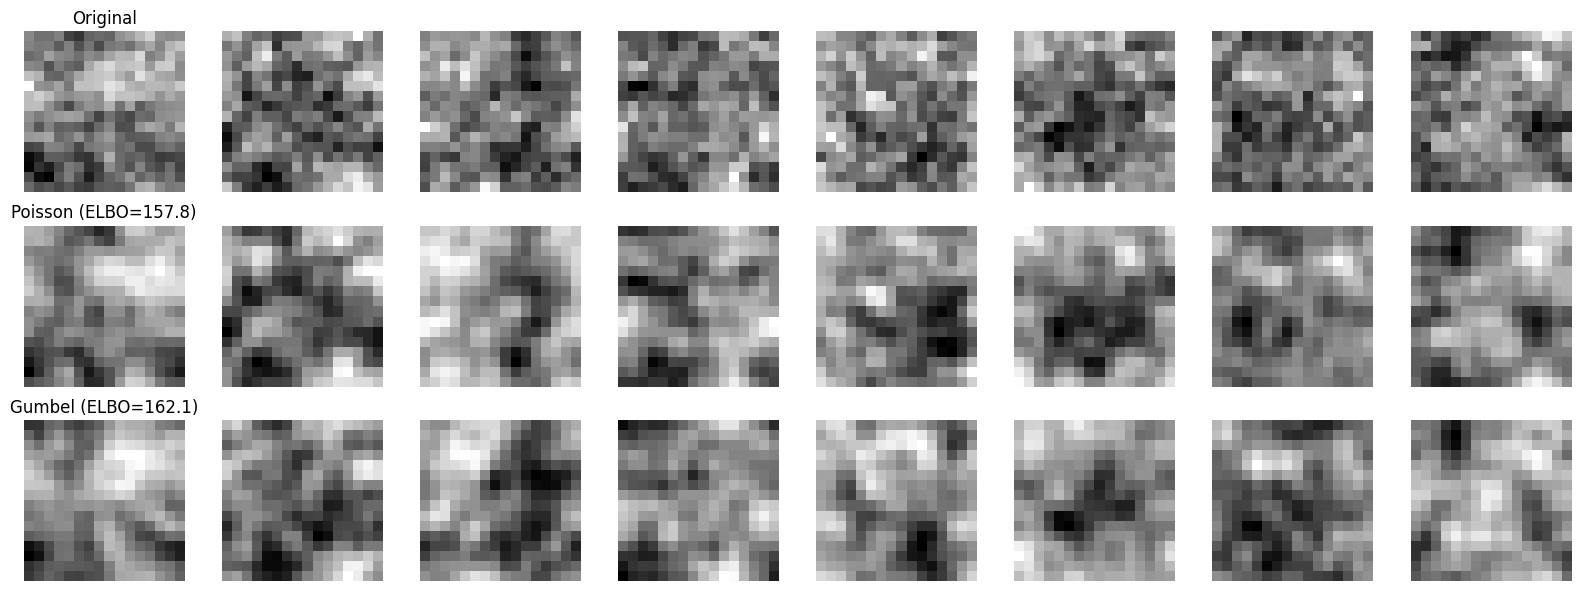


Poisson sparsity (this batch): 1.0000
Gumbel sparsity (this batch): 1.0000


In [9]:
from base.dataset import make_dataset

# Load test data
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
trn_data, vld_data, tst_data = make_dataset(dataset='vH16', device=torch.device('cpu'), load_dir='Datasets')

# Get a batch of test images
dl_vld = torch.utils.data.DataLoader(vld_data, batch_size=8, shuffle=True)
x_batch = next(iter(dl_vld))[0]

fig, axes = plt.subplots(3, 8, figsize=(16, 6))

# Original images
for i in range(8):
    axes[0, i].imshow(x_batch[i, 0].numpy(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=12)

# Poisson reconstructions
if best_poisson_model is not None:
    best_poisson_model = best_poisson_model.to(device)
    with torch.no_grad():
        x_gpu = x_batch.to(device)
        _, _, spks_p, y_p = best_poisson_model(x_gpu)
    for i in range(8):
        axes[1, i].imshow(y_p[i, 0].cpu().numpy(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title(f'Poisson (ELBO={best_poisson_config["neg_elbo"]:.1f})', fontsize=12)
    best_poisson_model = best_poisson_model.cpu()

# Gumbel reconstructions
if best_gumbel_model is not None:
    best_gumbel_model = best_gumbel_model.to(device)
    with torch.no_grad():
        x_gpu = x_batch.to(device)
        _, _, spks_g, y_g = best_gumbel_model(x_gpu)
    for i in range(8):
        axes[2, i].imshow(y_g[i, 0].cpu().numpy(), cmap='gray')
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_title(f'Gumbel (ELBO={best_gumbel_config["neg_elbo"]:.1f})', fontsize=12)
    best_gumbel_model = best_gumbel_model.cpu()

plt.tight_layout()
plt.savefig('./figures/sweep_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPoisson sparsity (this batch): {(spks_p > 0).float().mean().item():.4f}")
print(f"Gumbel sparsity (this batch): {(spks_g > 0).float().mean().item():.4f}")

## Summary

### Key Findings

**Temperature is the dominant factor:**
- Higher temperature (0.4) dramatically improves ELBO (~158 vs ~178 at temp=0.01)
- This holds for both Poisson and Gumbel distributions

**Poisson outperforms Gumbel:**
- Best Poisson: ELBO = 157.77 (temp=0.4, n_exp=256)
- Best Gumbel: ELBO = 162.13 (temp=0.4, n_cutoff=6)
- ~4.4 point ELBO difference

**N parameter has different effects:**
- Poisson: n_exp has minimal impact (16, 64, 256 all similar)
- Gumbel: n_cutoff matters - larger is better (6 > 4 > 2)

**Annealing:**
- Annealing keeps all neurons active (512/512)
- Without annealing, some collapse (~468/512 active)
- But ELBO is similar either way

**Sparsity patterns differ:**
- Poisson: Higher lifetime sparsity (~0.84) - neurons fire more selectively
- Gumbel: Lower lifetime sparsity (~0.29-0.42) - more uniform activation